# M2 B1 - Reprendre et fiabiliser le pipeline de préparation des données

## Étape 1 : Prendre en main le pipeline existant

En synthèse :
le pipeline proposé effectue des actions problématiques dans un contexte ML :

- Nettoyage agressif : exclusion de certaines variables sans justification, `clean_data(df)` peut entrainer une perte impotante de données
- Imputation naive : `fix_amounts` remplace les valeurs nulles et mal formatées par la moyenne des montants => introction d'un biais fort
- Encodage partiel : pas de distinction des variable catégorielles
- Scalling appliqué à toutes les données avant le split Test/train : entraine une fuite de données (data leakage) et biaise l'accuracy
- Random_State non défini : non reproductible

En conclusion, ce pipeline est :

- non robuste
- non reproductible en production
- potentiellement biaisé

## Étape 2 : Auditer la qualité des données sources

L'objectif de l'audit des données est d'identifier les problèmes de qualité pouvant générer des incohérences et des biais lors de l'entrainement et évaluation du modèle. Les données soumises à l'entrainement doivent être le plus propre possible afin d'assurer une bonne performance du modèle et des résultats honêtes. En d'autres termes, l'audit conditionne la fiabilité, la conformité et la crédibilité du modèle.

Cette étape va nous permettre de quantifier les problématiques liées aux données : doublons, valeurs manquantes , valeurs aberrantes, incohérences de format ou de type.

### 1 - Chargement du dataset
Contrairement au script, nous allons charger l'entièreté du Dataset afin de réaliser l'audit sur l'integralité des données. C'est le résultat de l'audit qui permettra d'exclure ou pas certaines variables (colonnes).

In [134]:
import sys
import sqlite3
import pandas as pd

# Chemin vers la base de données Finova Credits
DB_PATH = "finova_credits.db"

# Fonction de chargement des données depuis la base de données
#      Contrairement au script, On charge toutes les colonnes de la table dossiers_credit sans filtre     

def load_data():
    """Charge les dossiers de crédit depuis la base."""
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql("SELECT * FROM dossiers_credit", conn)
    conn.close()
    df.to_csv("dossiers_credit.csv", index=False)
    return df


df = load_data()

# Résumé du dataset
summary = {
    "nb_lignes": df.shape[0],
    "nb_colonnes": df.shape[1],
    "colonnes": list(df.columns)
}
    
print("Résumé du dataset")
print("-" * 30)
print(f"Nombre de lignes   : {summary['nb_lignes']}")
print(f"Nombre de colonnes : {summary['nb_colonnes']}")
    
print("\nListe des colonnes :")

# Liste des colonnes, type, Nb de valeurs nulles, Nb de valeurs distinctes 
for i, col in enumerate(summary["colonnes"], 1):
    dtype = df[col].dtype
    nb_nulls = df[col].isnull().sum()
    nb_uniques = df[col].nunique(dropna=True)

    print(f"{i:02d}. {col:<25} | type={str(dtype):<10} | nulls={nb_nulls:<5} | uniques={nb_uniques}")



Résumé du dataset
------------------------------
Nombre de lignes   : 1025
Nombre de colonnes : 33

Liste des colonnes :
01. numero_client             | type=object     | nulls=0     | uniques=1007
02. nom                       | type=object     | nulls=0     | uniques=366
03. prenom                    | type=object     | nulls=0     | uniques=200
04. sexe                      | type=object     | nulls=0     | uniques=2
05. date_naissance            | type=object     | nulls=0     | uniques=951
06. email                     | type=object     | nulls=0     | uniques=999
07. telephone_mobile          | type=object     | nulls=0     | uniques=1000
08. adresse                   | type=object     | nulls=0     | uniques=996
09. code_postal               | type=object     | nulls=0     | uniques=997
10. ville                     | type=object     | nulls=0     | uniques=850
11. iban                      | type=object     | nulls=0     | uniques=1000
12. num_secu                  | type=objec

 ### 2 - Identification des valeurs manquantes 

In [135]:
missing = df.isna().sum()
missing_pct = (missing / total * 100).round(2)

# Classement des colonnes par nb de valeurs manquantes
result = pd.DataFrame({
    "nb_manquants": missing,
    "pct_manquants": missing_pct
}).sort_values(by="pct_manquants", ascending=False)

# on affiche que les colonnes ayant des valeurs manquantes
display(result[result["nb_manquants"] > 0])

,nb_manquants,pct_manquants
epargne,81,7.90
anciennete_emploi,51,4.98
montant_credit,20,1.95


### 3 - Identification des doublons

#### Doublons Techniques
Il s'agit d'identifier des lignes dont toutes les vairables sont identiques => purs doublons

In [136]:
total = len(df)
duplicates = df.duplicated().sum()


result = {
    "nb_doublons": duplicates,
    "pct_doublons": round(duplicates / total * 100, 2)
}

print("Audit des doublons techniques")
print("-" * 30)
print(f"Nombre de doublons : {result['nb_doublons']}")
print(f"Pourcentage        : {result['pct_doublons']} %")


Audit des doublons techniques
------------------------------
Nombre de doublons : 18
Pourcentage        : 1.76 %


#### Doublons Fonctionnels
Il s'agit d'identifier des lignes dont certaines variable dites "clé d'unicité" sont identiques => doublons fonctionnels
les variables pouvant identifier de manière unique un enregistrement sont :
   - numero_client
   - nom + prénom + date de naissance : un homonyme est toujours possible, avec la même date de naissance, moins probable
   - email
   - on peut également combiner téléphone, adresse, etc...

Pour l'exercice on cherche les doublons sur l'aemail

In [137]:
cols = ["email", "num_secu", "numero_client"]

total = len(df)

for col in cols:
    duplicates = df.duplicated(subset=[col]).sum()

    print(f"\nAudit des doublons - colonne : {col}")
    print("-" * 40)
    print(f"Nombre de doublons : {duplicates}")
    print(f"Pourcentage        : {round(duplicates / total * 100, 2)} %")

# print("\n")
# print(df[df.duplicated()].head(10))


Audit des doublons - colonne : email
----------------------------------------
Nombre de doublons : 26
Pourcentage        : 2.54 %

Audit des doublons - colonne : num_secu
----------------------------------------
Nombre de doublons : 25
Pourcentage        : 2.44 %

Audit des doublons - colonne : numero_client
----------------------------------------
Nombre de doublons : 18
Pourcentage        : 1.76 %


### 4 - Valeurs aberrantes

Cette étape consiste à identifier les incohérences de type, de format et de valeur sur l'ensemble des colonnes du dataset.
Pour cibler les analyses, on affiche un résumé des données de chaque colonne : type, nb valeurs nulles, min, max, exemples


In [139]:
# Détection des types réels vs attendus
result = []

for col in df.columns:
    
    # tentative conversion numérique
    converted = pd.to_numeric(df[col], errors="coerce")

    # détection type réel
    is_numeric = converted.notna().sum() / len(df) > 0.7

    if is_numeric:
        min_val = converted.min()
        max_val = converted.max()
    else:
        # min/max ordre alphabétique pour texte
        non_null = df[col].dropna().astype(str)
        min_val = non_null.min() if len(non_null) > 0 else None
        max_val = non_null.max() if len(non_null) > 0 else None
    
    result.append({
        "variable": col,
        "dtype_pandas": str(df[col].dtype),
        "nb_nulls": df[col].isnull().sum(),
        "pct_nulls": round(df[col].isnull().mean() * 100, 2),
        "nb_valeurs_distinctes": df[col].nunique(),
        "min": min_val,
        "max": max_val,
        "exemples": df[col].dropna().astype(str).head(3).tolist()
    })

result_df = pd.DataFrame(result).sort_values(by="pct_nulls", ascending=False)

display(result_df)


,variable,dtype_pandas,nb_nulls,pct_nulls,nb_valeurs_distinctes,min,max,exemples
17,epargne,object,81,7.90,5,pas d'épargne connue,épargne > 1000,"[épargne < 100, épargne < 100, épargne < 100]"
18,anciennete_emploi,object,51,4.98,5,1-4 ans,sans emploi,"[4-7 ans, 4-7 ans, 1-4 ans]"
16,montant_credit,object,20,1.95,910,-3031.0,15945.0,"[1503, 2406, 2576]"
0,numero_client,object,0,0.00,1007,FIN-100000,FIN-200006,"[FIN-100527, FIN-100359, FIN-100447]"
1,nom,object,0,0.00,366,Adam,Étienne,"[Buisson, Marty, Diaz]"
5,email,object,0,0.00,999,adrien.baron@gmail.com,étienne.tessier@orange.fr,"[luc.buisson@outlook.fr, anastasie.marty@free...."
6,telephone_mobile,object,0,0.00,1000,600307562.0,33798926256.0,"[0646498931, 0602203173, 0747733294]"
3,sexe,object,0,0.00,2,F,M,"[M, F, M]"
2,prenom,object,0,0.00,200,Adrien,Étienne,"[Luc, Anastasie, Christophe]"
8,code_postal,object,0,0.00,997,1109,97693,"[55284, 11446, 93526]"


Le tableau ci-dessus montre déjà quelques incohérences en terme de type de données attendu pour certaines colones :
   - `montant_credit` est identifié en objet alors qu'on s'attend à un nombre, apparait aussi une valeur négative.
   - `code_postal est` identifié en objet alors qu'on s'attend à un nombre (5 chiffres)
   - `duree_credit` : 999 est une valeur abérante
   - `age` : 0 et 123 sont des valeurs abérantes

En s'attardant sur la colonne montant_crédit, on s'aperçoit d'un certain nombre de problèmes lorsque l'on essaye de convertir en numérique.

In [140]:
# Détection d’erreurs de conversion

col = "montant_credit"
converted = pd.to_numeric(df[col], errors="coerce")
errors = converted.isna() & df[col].notna()

print("colonne :", col)
print("nb_erreurs_format :", errors.sum())
print("pct_erreurs :", round(errors.sum() / len(df) * 100, 2))


print("\nValeurs erronées uniques (top 20)")
print("Les valeurs ci-dessous ne peuvent pas être converties en numérique \n")
display(df.loc[errors, col].value_counts().head(20))



colonne : montant_credit
nb_erreurs_format : 25
pct_erreurs : 2.44

Valeurs erronées uniques (top 20)
Les valeurs ci-dessous ne peuvent pas être converties en numérique 



montant_credit
1559,00       1
1358,00       1
18424,00      1
1364,00       1
6224,00       1
2 442 EUR     1
6 314 EUR     1
1552,00       1
3 878 EUR     1
6 199 EUR     1
3092,00       1
1 546 EUR     1
10 961 EUR    1
802 EUR       1
1424,00       1
3195,00       1
2118,00       1
2 278 EUR     1
1 082 EUR     1
409 EUR       1
Name: count, dtype: int64

In [141]:
# Détection des virgules 
contains_comma = df[col].astype(str).str.contains(",")
print("⚠️ Nb Valeurs avec virgule :", contains_comma.sum())

# Détection des unités 
contains_currency = df[col].astype(str).str.contains("€|EUR", regex=True)
print("⚠️ Nb Valeurs avec devise :", contains_currency.sum())

# détection des valeurs négatives
negatives = converted < 0
print("⚠️ Nb Valeurs négatives :", negatives.sum())



⚠️ Nb Valeurs avec virgule : 12
⚠️ Nb Valeurs avec devise : 13
⚠️ Nb Valeurs négatives : 3


### 5. Visualisation des variables clés

**Note :** 
> lors de cette étape (audit) nous souhaitons visualiser les données pour avoir une première idée de leur distribution brute. Pour solutionner le problème de qualité de certaines données vu précédemment, nous ignorons simplement ces données dans les visualisations qui suivent. Cette étape sera cependant à reproduire une fois les données nettoyées pour éviter tout biais dans l'analyse ultérieure.


Variable : montant_credit
----------------------------------------
Type détecté : numérique
Stats clés :


count      980.000000
mean      3263.057143
std       2802.941476
min      -3031.000000
25%       1365.500000
50%       2325.500000
75%       3976.750000
max      15945.000000
Name: montant_credit, dtype: float64

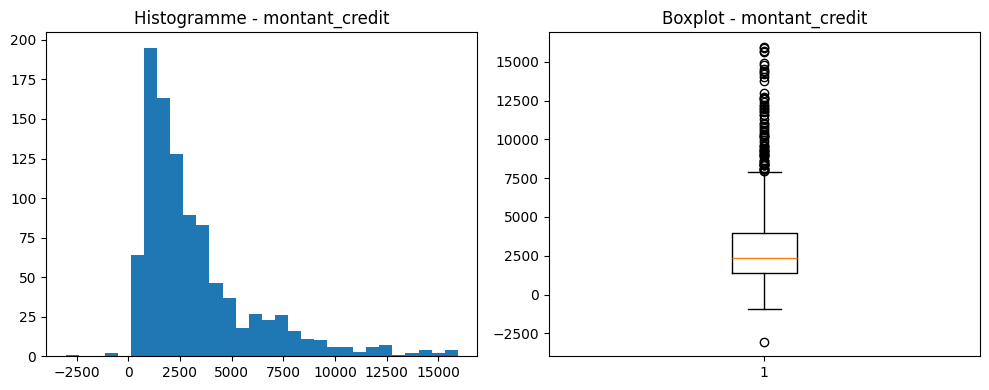


Variable : statut_compte_courant
----------------------------------------
Type détecté : catégoriel
Top modalités :


statut_compte_courant
pas de compte courant               399
solde < 100                         287
solde 100-200                       271
solde > 200 ou salaire domicilié     68
Name: count, dtype: int64

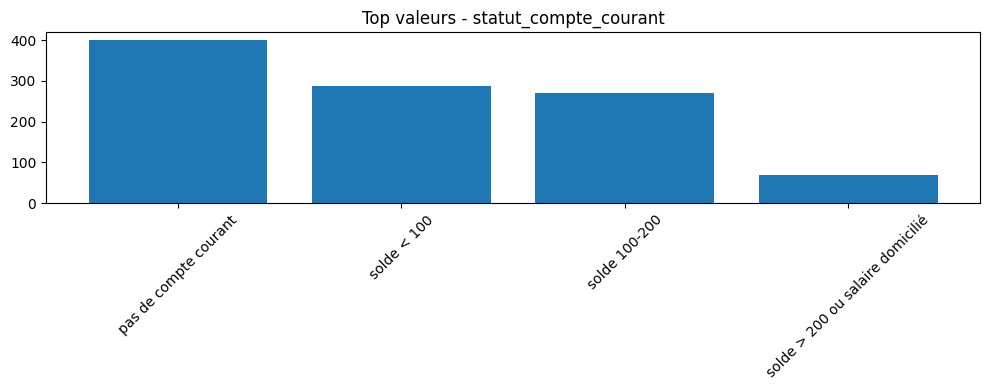


Variable : duree_credit_mois
----------------------------------------
Type détecté : numérique
Stats clés :


count    1025.000000
mean       23.748293
std        54.214157
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max       999.000000
Name: duree_credit_mois, dtype: float64

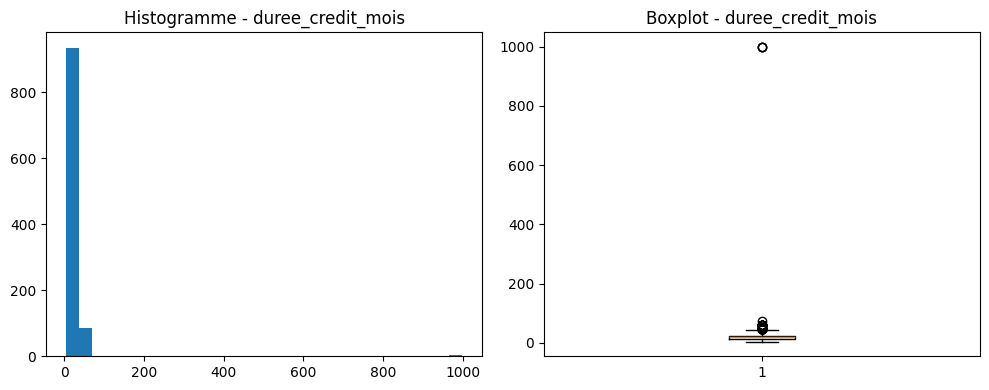


Variable : autres_credits
----------------------------------------
Type détecté : catégoriel
Top modalités :


autres_credits
aucun       833
banque      143
magasins     49
Name: count, dtype: int64

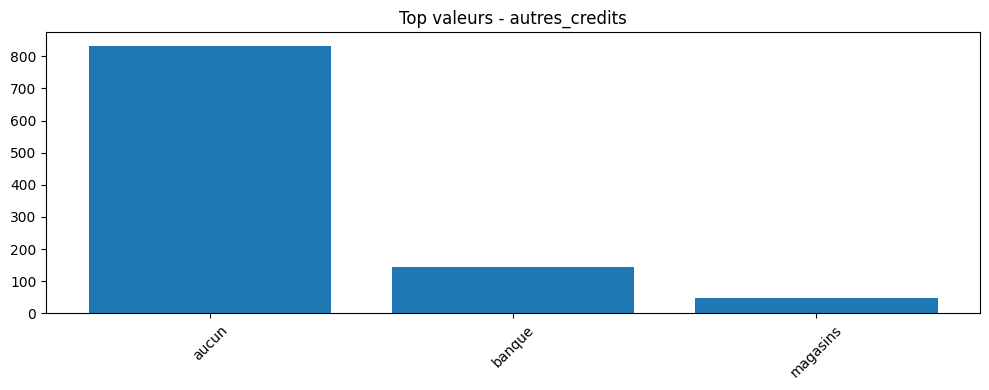


Variable : epargne
----------------------------------------
Type détecté : catégoriel
Top modalités :


epargne
épargne < 100           569
pas d'épargne connue    172
épargne 100-500          96
épargne 500-1000         64
épargne > 1000           43
Name: count, dtype: int64

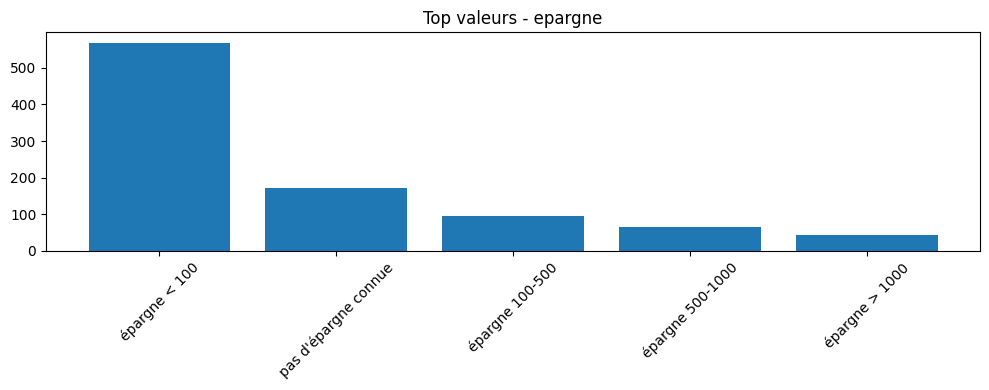


Variable : age
----------------------------------------
Type détecté : numérique
Stats clés :


count    1025.000000
mean       35.675122
std        12.201067
min         0.000000
25%        27.000000
50%        33.000000
75%        42.000000
max       123.000000
Name: age, dtype: float64

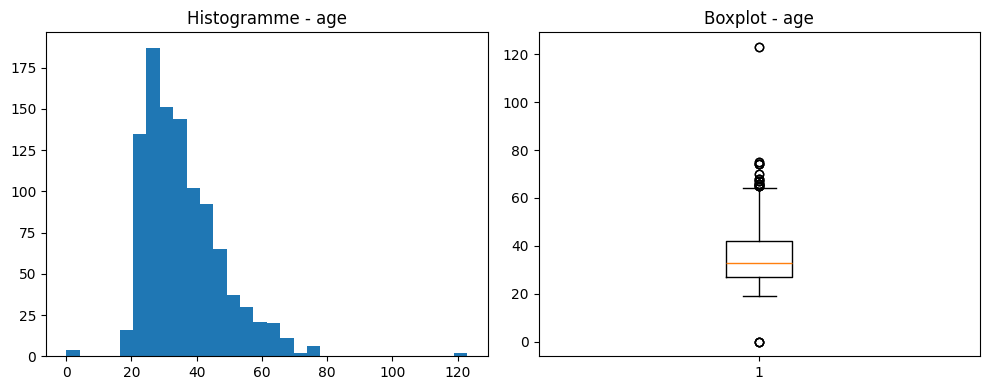


Variable : emploi
----------------------------------------
Type détecté : catégoriel
Top modalités :


emploi
employé qualifié                           645
non qualifié résident                      205
cadre / indépendant                        152
sans emploi / non qualifié non résident     23
Name: count, dtype: int64

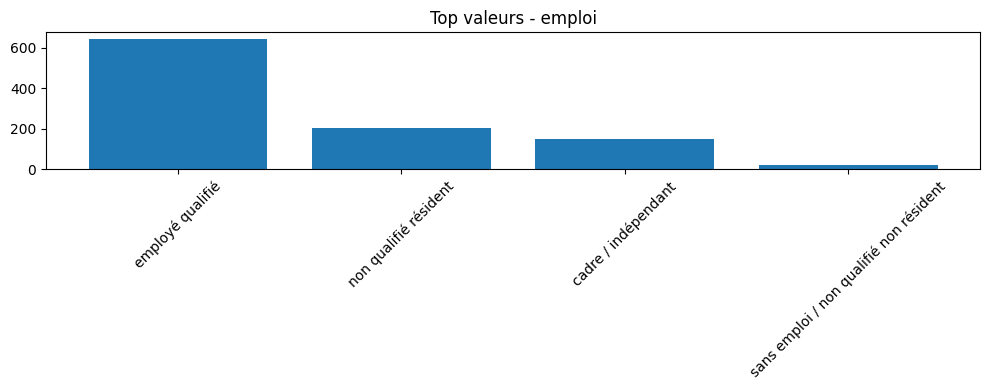


Variable : anciennete_emploi
----------------------------------------
Type détecté : catégoriel
Top modalités :


anciennete_emploi
1-4 ans        335
>= 7 ans       250
4-7 ans        166
< 1 an         164
sans emploi     59
Name: count, dtype: int64

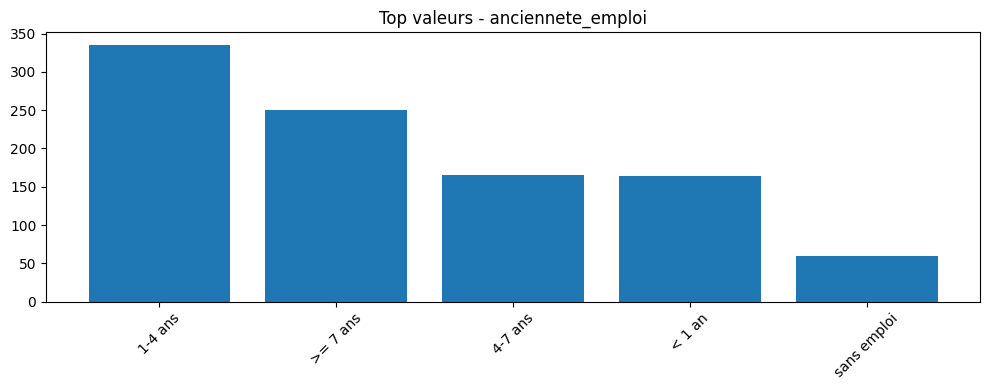


Variable : autres_debiteurs
----------------------------------------
Type détecté : catégoriel
Top modalités :


autres_debiteurs
aucun            931
garant            52
co-emprunteur     42
Name: count, dtype: int64

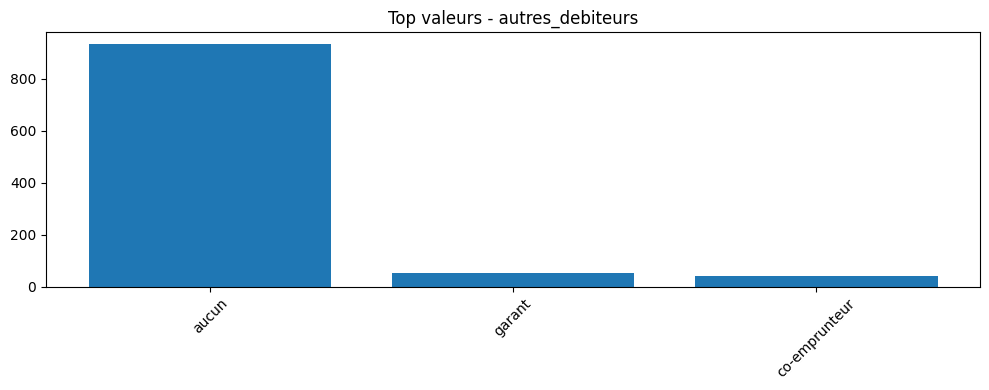


Variable : defaut
----------------------------------------
Type détecté : numérique
Stats clés :


count    1025.000000
mean        0.300488
std         0.458694
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: defaut, dtype: float64

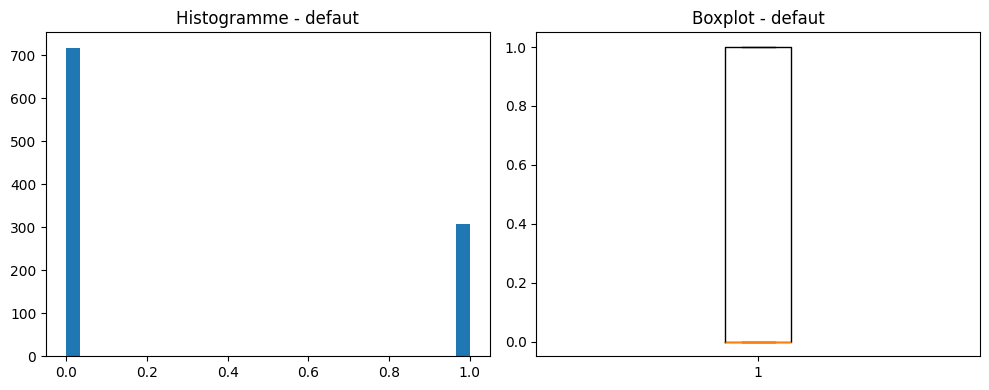

In [142]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_distributions(df, cols=None):
    """
    Visualisation automatique des distributions selon type de variable
    - numériques → histogramme + boxplot
    - catégorielles → barplot (top modalités)
    """

    for col in cols:  # limiter pour lisibilité
        print(f"\nVariable : {col}")
        print("-" * 40)

        # tentative conversion numérique
        converted = pd.to_numeric(df[col], errors="coerce")

        is_numeric = converted.notna().sum() / len(df) > 0.7  # seuil robuste

        plt.figure(figsize=(10, 4))

        # ============================
        # CAS VARIABLE NUMERIQUE
        # ============================
        if is_numeric:
            valid = converted.dropna()

            print("Type détecté : numérique")

            # stats clés
            print("Stats clés :")
            display(valid.describe())

            plt.subplot(1, 2, 1)
            plt.hist(valid, bins=30)
            plt.title(f"Histogramme - {col}")

            plt.subplot(1, 2, 2)
            plt.boxplot(valid)
            plt.title(f"Boxplot - {col}")

        # ============================
        # CAS VARIABLE CATEGORIELLE
        # ============================
        else:
            print("Type détecté : catégoriel")

            counts = df[col].value_counts().head(10)

            print("Top modalités :")
            display(counts)

            plt.bar(counts.index.astype(str), counts.values)
            plt.xticks(rotation=45)
            plt.title(f"Top valeurs - {col}")

        plt.tight_layout()
        plt.show()

# sélection de quelques variables clés pour ne pas surcharger le notebook
cols = [
    "montant_credit",
    "statut_compte_courant",
    "duree_credit_mois",
    "autres_credits",
    "epargne",
    "age",
    "emploi",
    "anciennete_emploi",
    "autres_debiteurs",
    "defaut"
]
plot_distributions(df, cols)

# plot_distributions(df, max_cols=10)  # on limite à 10 variables pour ne pas surcharger le notebook


### Conclusion 

En thérorie, l'audit d'un dataset est une opération longue car elle nécessite l'analyse de chaque variable du jeu de données. Cette analyse doit porter sur 2 axes : 
   - technique : vérification du bon typage, et de la présence de valeur pour la variable
   - fonctionel : vérification de pertinence fonctionnelle d'une valeur (par exemple : montant de crédit négatif, age < 18 ans)

Ci-dissous une liste de vérification à faire pour chaque variable :

01. `numero_client` : vérification que la colonne est bien formattée : FIN-6 digits         
02. `sexe` : vérification que la colonne ne contient que 2 valeurs                  
03. `code_postal` : vérification que le code postal est bien formatté sur 5 digit           
04. `statut_compte_courant` : vérification d'un nombre distinct de valeurs
05. `duree_credit_mois` : vérification qu'il s'agit d'un nombre positif et dans la limite d'un certain range (ex : crédit sur 999 mois = 83 ans, ce n'est pas possible)     
06. `historique_credit` : vérification d'un nombre distinct de valeurs      
07. `objet_credit` : vérification d'un nombre distinct de valeurs - liste de valeur           
08. `montant_credit` : vérification que le format est uniforme (un nombre, sans les unités) et que les montant est bien rationel et conforme (pas de chiffre négatif ou abérant)       
09. `epargne` : valeurs discrètes               
10. `anciennete_emploi` : liste de valeurs     
11. `taux_effort` :            
12. `statut_personnel_sexe` : 
13. `autres_debiteurs` :       
14. `anciennete_logement` : valeur numérique   
15. `biens` : valeur rationnelle                 
16. `age` : valeur numérique comprise entre un certain range : > 18 et < 80 (ex 123 est un valeur abérante)                   
17. `autres_credits` :  vérification d'un nombre distinct de valeurs - liste de valeur        
18. `logement` :  vérification d'un nombre distinct de valeurs - liste de valeur               
19. `nb_credits_existants` : nombre compris entre un certain range : de 1 à 4
20. `emploi` :  vérification d'un nombre distinct de valeurs - liste de valeur 
21. `nb_personnes_charge` : valeur numérique positive (-1 est une valeur abérante)   
22. `telephone_declare` : oui/non, toute autre valeur et abérante  
23. `travailleur_etranger` : oui/non, toute autre valeur et abérante
24. `defaut` : 1/0, toute autre valeur et abérante


On peut ensuite vérififer l'éxactitude de la relation entre certaines variables dépendantes. 

Par exemple :
   - l'age et la date de naissance soivent correspondre,
   - les premiers chiffres du numéro de sécurité sociale doivent correspondre au sexe et à la date de naissance

Au final, certains champs peuvent ne pas être retenus pour des raisons éthiques (*cf Brief N° 2*) ou parcequ'ils n'influent pas sur le modèle : 
   - email, numéro de téléphone, IBAN, sexe, etc...



## Étape 3 : Corriger et enrichir les traitements

Nous allons procéder selon les étapes suivantes :

> 3.1 - Dédoublonnage des données
> 
> 3.2 - Correction de format (conversions et uniformisation des formats)
> 
> 3.3 - traitement des valeurs manquantes et abérantes
> 
> 3.4 - Renue des encodages

### 3.1 Dédoublonnage
Pour l'exerice, nous procédons uniquement au dédoublonnage technique mais il faudrait en théorie procéder aussi à un dédoublonnage fonctionnel (analyse des doublons masqués, et définition des règles de déduplication)

In [144]:
import pandas as pd
import numpy as np

# ============================
# 0. SAUVEGARDE DATASET ORIGINAL
# ============================
df_original = df.copy(deep=True)

# Dataset de travail
df_clean = df.copy(deep=True)


# ============================
# 3.1. DÉDOUBLONNAGE
# ============================
print("---- Dédoublonnage ----")
nb_avant = len(df_clean)

df_clean = df_clean.drop_duplicates()

nb_apres = len(df_clean)
print(f"Lignes avant : {nb_avant}")
print(f"Lignes après : {nb_apres}")
print(f"Doublons supprimés : {nb_avant - nb_apres}")


---- Dédoublonnage ----
Lignes avant : 1025
Lignes après : 1007
Doublons supprimés : 18


### 3.2 Formattage
Pour l'exerice, nous procédons au formattage des varaibles suivantes :
- `montant_crédit` : uniformiser le format (supprimer les virgules, la Currency, prendre la valeur absolue) et convertir en numérique
- `date_naissance` : uniformiser le format date. On veut DD/MM/YYYY et pas DD.MM.YYYY

In [183]:

# ============================
# 3.2. TRAITEMENT DES FORMATS
# ============================

print("\n---- Nettoyage des formats ----")

# 3.2.1 montant_crédit
col = "montant_credit"

df_clean[col] = (
    df_clean[col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("€", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").abs()


# 3.2.2 date de naissance
col_date = "date_naissance"

df_clean[col_date] = df_clean[col_date].astype(str).str.replace(".", "/", regex=False)
df_clean[col_date] = pd.to_datetime(df_clean[col_date], format="%d/%m/%Y", errors="coerce")



---- Nettoyage des formats ----


### 3.3 Traintement des valeurs manquantes / abérantes

Le traitement des valeurs manquantes est une étape cruciale, car elles peuvent biaiser les modèles ou réduire leur performance.

Quelques options :

1. Suppression des valeurs manquantes : lorsque les données manquantes sont aléatoires et représentent une faible proportion (< 5-10 %)
    - supression des lignes (observation)
    - suppression des colonnes (variables)


2. Imputation simple (basique) : Pour des jeux de données avec peu de valeurs manquantes ou des distributions simples
    - Imputation par la moyenne/médiane/mode : Remplacer les valeurs manquantes par la moyenne (pour des données numériques), la médiane (robuste aux outliers) ou le mode (pour des données catégorielles)
    - Imputation par une valeur constante : Remplacer par une valeur arbitraire 


3. Imputation avancée (modélisation) : Pour des jeux de données complexes avec des patterns de valeurs manquantes non aléatoires ou des relations entre variables.
    - Imputation par modèle statistique
    - Imputation par apprentissage profond
    - Imputation par méthodes avancées
    - Imputation par données externes


En théorie, il convient de 
   1. Analyser les patterns de valeurs manquantes 
   2. Comparer les méthodes : Tester plusieurs approches et évaluer leur impact sur les performances du modèle.
   3. Valider l’imputation 
   4. Documenter les choix 


**Valeurs manquantes** : Dans le cadre de ce exercice, nous choisissons de traiter les valeurs manquantes des variables suivantes :

- `Epargne` (7,9% de valeurs nulles) : c'est une variable catégorielle ordinale. Souvent, une valeur nulle peut indiquer un client sans épargne
   + **proposition** : valorisation des valeurs nulles à "pas d'épargne connue"
- `anciennete_emploi` (4,98% de valeurs nulles) : variable numérique discrète pouvant avoir un fort impact sur defaut
   + **proposition** : peut être corrélée au type d'emploi
- `montant_credit` (2% de valeurs nulles) : variable numérique critique, c'est une feature clé
   + **proposition** : c'est une variable sensible dont la distribution n'est pas normale. Prendre la moyenne ou la mediane pour les valeurs manquantes/abérantes pourrait introduire un biais.  Dans ce cas, et vu la faible quantité de valeur nulle (2%) on excluera ces observations du dataset final.

**Valeurs abérantes** : Dans le cadre de ce exercice, nous choisissons de traiter les valeurs abérantes des variables suivantes :
- `age` : les dates de naissance des client dont l'age est abérant étant correctement rensignées dans la base, nous pouvons en déduire l'age et corriger cette donnée dans le dataset
- `duree_credit_mois` : le nombre d'observations ayant une durée crédit abérante (999) étant de 3, nous choisissons de filtrer ces lignes du dataset

En préambule, on fait une comparaison rapide entre dataset original et dataset nettoyé

In [186]:
# ============================
# 3.3.1. COMPARAISON ORIGINAL vs CLEAN
# ============================

print("\n---- Comparaison ----")

print("Shape original :", df_original.shape)
print("Shape clean    :", df_clean.shape)

print("\nValeurs manquantes (original) :")
print(df_original.isna().sum())

print("\nValeurs manquantes (clean) :")
print(df_clean.isna().sum())

print("\nNombre d'âges corrigés :", df_clean["age_corrige"].sum())


---- Comparaison ----
Shape original : (1025, 33)
Shape clean    : (1007, 35)

Valeurs manquantes (original) :
numero_client             0
nom                       0
prenom                    0
sexe                      0
date_naissance            0
email                     0
telephone_mobile          0
adresse                   0
code_postal               0
ville                     0
iban                      0
num_secu                  0
statut_compte_courant     0
duree_credit_mois         0
historique_credit         0
objet_credit              0
montant_credit           20
epargne                  81
anciennete_emploi        51
taux_effort               0
statut_personnel_sexe     0
autres_debiteurs          0
anciennete_logement       0
biens                     0
age                       0
autres_credits            0
logement                  0
nb_credits_existants      0
emploi                    0
nb_personnes_charge       0
telephone_declare         0
travailleur_etranger

In [187]:
# ============================
# 3.3. TRAITEMENT VALEURS MANQUANTES / ABERRANTES
# ============================

print("\n---- Traitement des valeurs ----")

# --- 3.1 Epargne ---
df_clean["epargne"] = df_clean["epargne"].fillna("pas d'épargne connue")


# --- 3.2 Age aberrant ---
def compute_age(date_naissance):
    if pd.isna(date_naissance):
        return np.nan
    today = pd.Timestamp.today()
    return today.year - date_naissance.year - (
        (today.month, today.day) < (date_naissance.month, date_naissance.day)
    )

mask_age_aberrant = (df_clean["age"] < 18) | (df_clean["age"] > 100)

# (option audit)
df_clean["age_original"] = df_clean["age"]

df_clean.loc[mask_age_aberrant, "age"] = df_clean.loc[mask_age_aberrant, "date_naissance"].apply(compute_age)

# Flag de correction
df_clean["age_corrige"] = mask_age_aberrant.astype(int)



---- Traitement des valeurs ----


### 3.4 Encodage

Avant de réaliser l'encodage, on sélectionne les variables à intégrer dans le dataset : Ces variables correspondent au coeur de métier banque/finance/crédit et sont reconnues pour avoir un fort pouvoir prédictif. On choisit de garder les variables ci-dessous :

- duree_credit_mois
- historique_credit
- objet_credit
- montant_credit
- epargne
- anciennete_emploi
- taux_effort
- autres_debiteurs
- anciennete_logement
- biens
- autres_credits
- logement
- nb_credits_existants
- emploi
- nb_personnes_charge
- telephone_declare
- travailleur_etranger
- age
- statut_compte_courant

Par ailleurs, les variables ci-dessous ne sont pas conservées car elle n'ont pas ou peu de pouvoir prédictif, certaines peuvent contituer un risque legal (RGPD) ou éthique, et ne pas exclure des variables non essentielles peut ajouter du bruit/overfitting au modèle.

- numero_client : n'apporte pas valeur prédictive
- nom : données personnelle, n'apporte pas valeur prédictive
- prenom : données personnelle, n'apporte pas valeur prédictive
- email : données personnelle, n'apporte pas valeur prédictive
- telephone_mobile : données personnelle, n'apporte pas valeur prédictive
- adresse : données personnelle, n'apporte pas valeur prédictive
- code_postal : peut entrainer un biais
- ville : peut entrainer un biais
- iban : n'apporte pas valeur prédictive
- num_secu : n'apporte pas valeur prédictive
- date_naissance (redondance avec age)

Enfin, la question se pose pour les 3 varaibles : `sexe`, `statut_personnel_sexe`, `travailleur_etranger`. La décision de les utiliser doit être rigoureusement motivée, expliquée et débatue. Ces variables peuvent entrainer un biais de discrimination et être sujettes à polémique. Nous excluerons donc ces variables dans le cadre de cet exercice. 


In [170]:
# ============================
# 3.4.1 PREPARATION DES DATASET, SÉPARATION FEATURES / TARGET
# ============================

target = "defaut"

cols_to_drop = [
    "numero_client", "nom", "prenom", "email",
    "telephone_mobile", "adresse", "code_postal", "ville",
    "iban", "num_secu", "date_naissance", "sexe", "travailleur_etranger", "statut_personnel_sexe", "age_original", "age_corrige"
]

df_model = df_clean.drop(columns=cols_to_drop)

# séparation features / target
X = df_model.drop(columns=[target])
y = df_model[target]

print("Nb features :", X.shape[1])
print("Nb observations :", X.shape[0])

Nb features : 18
Nb observations : 1007


Nous passons à l'étape feature engineering / preprocessing ML. Les principaux objectifs sont :

- encoder les variables catégorielles
- normaliser les variables numériques
- produire un dataset prêt pour le ML (X, y)

Les étapes sont : df_clean → séparation num / cat → encodage + scaling → dataset final

Note : on utilise `ColumnTransformer` (skelearn)

In [171]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# ============================
# 3.4.2. IDENTIFICATION DES VARIABLES
# ============================

# Variables numériques
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Variables catégorielles
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numériques :", num_cols)
print("Variables catégorielles :", cat_cols)


# ============================
# 3.4.3. PIPELINE DE PRÉPROCESSING
# ============================

# Variables numériques → scaling
num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Variables catégorielles → encodage
cat_pipeline = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore")) # handle_unknown="ignore" : évite une erreur si une nouvelle catégorie est détectée en prod
])

# Combinaison
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)



Variables numériques : ['duree_credit_mois', 'montant_credit', 'taux_effort', 'anciennete_logement', 'age', 'nb_credits_existants', 'nb_personnes_charge']
Variables catégorielles : ['statut_compte_courant', 'historique_credit', 'objet_credit', 'epargne', 'anciennete_emploi', 'autres_debiteurs', 'biens', 'autres_credits', 'logement', 'emploi', 'telephone_declare']


## Étape 4 : Reconstruire les jeux d'entraînement et de test

Voir les commentaires dans le script `pipeline_v1.py`

In [174]:

# ============================
# 4.1 TRAIN / TEST SPLIT
# ============================
# ne pas oublier le random_state pour la reproductibilité
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ============================
# 4.2 APPLICATION DU PIPELINE
# ============================
# on applique la transformation après le split test/train
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


# ============================
# 4.3 CONTRÔLE
# ============================

print("\nShape train :", X_train_processed.shape)
print("Shape test :", X_test_processed.shape)


Shape train : (805, 56)
Shape test : (202, 56)


##  Étape 5 : Formater et stocker

Formater les données nettoyées pour leur stockage en base (typage, schéma, conventions de nommage).+
Objectif : charger le dataset clean_df dans la base SQLlite

In [188]:
# Contenu du dataset : colonnes et types python

dtypes_table = pd.DataFrame({
    "numero_colonne": range(1, len(df_model.columns) + 1),##
    "nom_colonne": df_model.columns,
    "type": df_model.dtypes.astype(str)
})

print(dtypes_table)


                       numero_colonne            nom_colonne     type
statut_compte_courant               1  statut_compte_courant   object
duree_credit_mois                   2      duree_credit_mois    int64
historique_credit                   3      historique_credit   object
objet_credit                        4           objet_credit   object
montant_credit                      5         montant_credit  float64
epargne                             6                epargne   object
anciennete_emploi                   7      anciennete_emploi   object
taux_effort                         8            taux_effort    int64
autres_debiteurs                    9       autres_debiteurs   object
anciennete_logement                10    anciennete_logement    int64
biens                              11                  biens   object
age                                12                    age  float64
autres_credits                     13         autres_credits   object
logement            

In [178]:
# ============================
# 5.1 CONVERSION DES TYPES
# ============================
import pandas as pd

# Copie sécurité
df_db = df_model.copy()

# --- Cast types compatibles SQLite ---

# numériques
df_db["age"] = df_db["age"].astype("Int64")
df_db["montant_credit"] = df_db["montant_credit"].astype(float)

# booléens → INTEGER (0/1)
# bool_cols = df_db.select_dtypes(include="bool").columns
# df_db[bool_cols] = df_db[bool_cols].astype(int)

# dates → string ISO (important SQLite)
date_cols = df_db.select_dtypes(include="datetime64[ns]").columns
for col in date_cols:
    df_db[col] = df_db[col].dt.strftime("%Y-%m-%d")

# textes → string
cat_cols = df_db.select_dtypes(include="object").columns
df_db[cat_cols] = df_db[cat_cols].astype("string")

# gestion NULL
df_db = df_db.where(pd.notnull(df_db), None)

# Ajout de clé primaire
df_db["id"] = range(1, len(df_db) + 1)


# Vérification des types après conversion
types_db = pd.DataFrame({
    "numero_colonne": range(1, len(df_db.columns) + 1),
    "nom_colonne": df_db.columns.tolist(),
    "type_pandas": df_db.dtypes.astype(str).values
})

print(types_db)



    numero_colonne            nom_colonne type_pandas
0                1  statut_compte_courant      string
1                2      duree_credit_mois       int64
2                3      historique_credit      string
3                4           objet_credit      string
4                5         montant_credit     float64
5                6                epargne      string
6                7      anciennete_emploi      string
7                8            taux_effort       int64
8                9       autres_debiteurs      string
9               10    anciennete_logement       int64
10              11                  biens      string
11              12                    age       Int64
12              13         autres_credits      string
13              14               logement      string
14              15   nb_credits_existants       int64
15              16                 emploi      string
16              17    nb_personnes_charge       int64
17              18      tele

In [179]:
# ============================
# 5.2 SCRIPT DE CREATION DE LA TABLE
# ============================

import sqlite3

def map_sqlite_type(dtype):
    dtype = str(dtype)
    
    if "int" in dtype:
        return "INTEGER"
    elif "float" in dtype:
        return "REAL"
    elif "datetime" in dtype:
        return "TEXT"  # dates stockées en ISO
    else:
        return "TEXT"


def generate_create_table(df, table_name="credit_clients"):
    columns_sql = []
    
    for col in df.columns:
        col_type = map_sqlite_type(df[col].dtype)
        
        # Gestion clé primaire
        if col == "id":
            columns_sql.append(f"{col} INTEGER PRIMARY KEY")
        else:
            columns_sql.append(f"{col} {col_type}")
    
    columns_sql_str = ",\n    ".join(columns_sql)
    
    create_stmt = f"""
CREATE TABLE IF NOT EXISTS {table_name} (
    {columns_sql_str}
);
"""
    
    return create_stmt


# Génération du script
sql_create = generate_create_table(df_db)

# Vérification du script
print(sql_create)



CREATE TABLE IF NOT EXISTS credit_clients (
    statut_compte_courant TEXT,
    duree_credit_mois INTEGER,
    historique_credit TEXT,
    objet_credit TEXT,
    montant_credit REAL,
    epargne TEXT,
    anciennete_emploi TEXT,
    taux_effort INTEGER,
    autres_debiteurs TEXT,
    anciennete_logement INTEGER,
    biens TEXT,
    age TEXT,
    autres_credits TEXT,
    logement TEXT,
    nb_credits_existants INTEGER,
    emploi TEXT,
    nb_personnes_charge INTEGER,
    telephone_declare TEXT,
    defaut INTEGER,
    id INTEGER PRIMARY KEY
);



In [180]:
# ============================
# 5.3 CREATION DE LA TABLE ET CHARGEMENT SQL LITE
# ============================

# Connexion SQLite
conn = sqlite3.connect("credit.db")
cursor = conn.cursor()

# Suppression de la table
cursor.execute("DROP TABLE IF EXISTS credit_clients")

# Création table
cursor.execute(sql_create)

conn.commit()

# Chargement des données
df_db.to_sql("credit_clients", conn, if_exists="append", index=False)



1007

In [182]:
# ============================
# 5.4 VERIFICATION DE L'INTEGRITE
# ============================

# Connexion SQLite
conn = sqlite3.connect("credit.db")
cursor = conn.cursor()

# Vérification volumétrique
cursor.execute("SELECT COUNT(*) FROM credit_clients")
db_count = cursor.fetchone()[0]

print("Nb lignes dataset :", len(df_db))
print("Nb lignes DB      :", db_count)


# Vérification NULL critiques
cursor.execute("""
SELECT COUNT(*) 
FROM credit_clients
WHERE montant_credit IS NULL
""")
print("Montant_credit NULL :", cursor.fetchone()[0])


# Vérification agrégats
cursor.execute("""
SELECT MIN(montant_credit), MAX(montant_credit)
FROM credit_clients
""")
print("Min / Max montant :", cursor.fetchone())


# Vérification unicité PK
cursor.execute("""
SELECT COUNT(id), COUNT(DISTINCT id)
FROM credit_clients
""")
print("PK check :", cursor.fetchone())



df_check = pd.read_sql("""
SELECT id, age, montant_credit, defaut
FROM credit_clients
LIMIT 5
""", conn)

print(df_check)


conn.close()



Nb lignes dataset : 1007
Nb lignes DB      : 1007
Montant_credit NULL : 33
Min / Max montant : (250.0, 1842400.0)
PK check : (1007, 1007)
   id age  montant_credit  defaut
0   1  42          1503.0       0
1   2  23          2406.0       1
2   3  35          2576.0       0
3   4  27          4020.0       0
4   5  32          1530.0       1


## Étape 6 (Optionnelle) : Aller plus loin — fiabiliser dans le temps

On implémente 3 niveaux de contrôle :
    
1. Schéma attendu (structure)
   - colonnes obligatoires
   - types attendus

2. Règles de validité (data quality)
   - contraintes métier (âge, montant…)
   - valeurs autorisées

3. Seuils d’alerte (niveau dataset)
   - % de valeurs manquantes
   - % de valeurs aberrantes

**NOTE :** 
> le code ci-dessous ne présente pas une version exhaustive des tests et contoles qualités à effetuer. Il n'a pas été complètement testé. L'idée est d'illustrer l'approche proposée plus haut. On définit le schéma de données attendu et les controles à réaliser. On applique ensuite les controles sur le nouveau jeu de données reçu. Enfin, en cas de rejet du jeu de données, un rapport est émis pour expliquer le rejet (valeur invalides, valeurs manquantes, outliers, etc...)

Il conviendrait également de générer des jeux de tests pour tester l'ensemble des controles à effectuer sur le jeu de donnnées.

In [ ]:
# ============================
# 6.1 DEFINITION DES REGLES
# ============================

# exemple de schéma attendu, avec typage python
schema_expected = {
    "statut_compte_courant": "object",
    "duree_credit_mois": "int64",
    "historique_credit": "object",
    "objet_credit": "object",
    "montant_credit": "int64",
    "epargne": "object",
    "anciennete_emploi": "object",
    "taux_effort": "int64",
    "autres_debiteurs": "object",
    "anciennete_logement": "int64",
    "biens": "object",
    "age": "int64",
    "autres_credits": "object",
    "logement": "object",
    "nb_credits_existants": "int64",
    "emploi": "object",
    "nb_personnes_charge": "int64",
    "telephone_declare": "object",
    "defaut": "int64"
}

# on peut définir des contraintes sur les valeurs de données, par exemple : 
constraints = {
    "age": lambda x: (x >= 18) & (x <= 100),
    "montant_credit": lambda x: x > 0
}

# on peut imposer de valeurs pour certaines variables, afin d'éviter l'apparition de nouvelles valeurs qui pourrainet désatibiliser le modèle, par exemple :
allowed_values = {
    "logement": ["locataire", "proprietaire", "logé gratuitement"]
}

# seuils pour exclure le lot : valeurs manquantes, outliers => au delà de la valeur limite, le lot sera exclus
thresholds = {
    "missing_max_pct": 0.1,  # 10%
    "outliers_max_pct": 0.05
}


# ============================
# 6.2 VALIDATION DU SCHEMA
# ============================

def validate_dataset(df):
    report = []
    is_valid = True

    # =========================
    # 6.2.1. Vérification du schéma
    # =========================
    # on vérifie si la colonne existe. Si oui, on vérifie le type de la colonne
    for col in schema_expected:
        if col not in df.columns:
            report.append(f"Colonne manquante : {col}")
            is_valid = False
        else:
            if str(df[col].dtype) != schema_expectedreport.append(f"Type incorrect pour {col} (attendu {schema_expected[col]}, obtenu {df[col].dtype})")

    # =========================
    # 6.2.2. Contraintes métier
    # =========================
    # on compte le nombre de valeurs invalides
    for col, rule in constraints.items():
        if col in df.columns:
            invalid_count = (~rule(df[col])).sum()
            if invalid_count > 0:
                report.append(f"{invalid_count} valeurs invalides dans {col}")
                is_valid = False

    # =========================
    # 6.2.3 Valeurs autorisées
    # =========================
    for col, values in allowed_values.items():
        if col in df.columns:
            invalid = ~df[col].isin(values)
            if invalid.sum() > 0:
                report.append(f"Valeurs interdites dans {col}")
                is_valid = False

    # =========================
    # 6.2.4. Valeurs manquantes
    # =========================
    missing_pct = df.isna().mean()
    for col, pct in missing_pct.items():
        if pct > thresholds["missing_max_pct"]:
            report.append(f"Trop de valeurs manquantes dans {col} ({pct:.2%})")
            is_valid = False

    # =========================
    # 6.2.5. Outliers (IQR)
    # =========================
    for col in df.select_dtypes(include="number"):
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        outliers_pct = ((df[col] < lower) | (df[col] > upper)).mean()

        if outliers_pct > thresholds["outliers_max_pct"]:
            report.append(f"Trop d'outliers dans {col} ({outliers_pct:.2%})")
            is_valid = False

    return is_valid, report


# ============================
# 6.2 GESTION DU REJET AUTOMATIQUE
# ============================

is_valid, report = validate_dataset(df_new)

if not is_valid:
    print("LOT REJETÉ")
    
    for r in report:
        print(r)
    
    # Export rapport
    with open("rapport_erreur.txt", "w") as f:
        for r in report:
            f.write(r + "\n")

else:
    print("LOT VALIDE - Intégration OK")




## Conclusion

Le travail mené avait pour but de passer d’un pipeline initial opaque et potentiellement biaisé à une chaîne de traitement des données robuste, traçable et industrialisable, conforme aux exigences de qualité, d’auditabilité et de mise en production.

**1. Analyse de l'existant**

Cette phase a permis d’identifier des choix discutables (gestion des données, logique de découpage train/test), susceptibles d’impacter la qualité du modèle, notamment en introduisant des biais ou des fuites de données.

La suite propose de reprendre dans l'ordre les principales phases d'un pipeline de préparation de données

**2. Audit de la qualité des données**

Avant toute action ou correction sur les données, un audit complet du dataset source doit être réalisé :
   - quantification des valeurs manquantes par variable,
   - identification des doublons,
   - détection des valeurs aberrantes et incohérences de types/format,
   - analyse des distributions des variables clés.

Ce travail a permis de produire un état des lieux chiffré et traçable, servant de base à toutes les décisions de nettoyage.
Cette approche garantit une justification objective des traitements, indispensable en contexte réglementé (crédit, audit).

**3. Nettoyage et transformation – fiabilisation des données**

Le pipeline peut ensuite etre construit de manière rigoureuse :

   - dédoublonnage du dataset,
   - standardisation des formats (montants, dates),
   - traitement des valeurs manquantes avec des stratégies adaptées (imputation vs conservation),
   - correction des valeurs aberrantes en s’appuyant sur des règles métier (ex : recalcul d’âge).

Chaque décision doit être :

   - justifiée,
   - documentée,
   - traçable.

**4. Reconstruction rigoureuse train/test**

Une attention particulière doit être portée à la construction des jeux d’entraînement et de test.
L’analyse du pipeline initial a mis en évidence des risques de data leakage liés à l’ordre des opérations.
Le pipeline a été corrigé pour assurer que :
   - la séparation train/test est réalisée avant toute transformation influencée par les données,
   - aucune information du jeu de test ne fuit vers l’entraînement.

Cela garantit des performances réalistes du modèle, évitant les scores artificiellement optimistes.

**5. Structuration et stockage – préparation à la production**

Les données nettoyées sont ensuite :

   - formatées selon des conventions standardisées (naming, typage),
   - alignées avec un schéma SQL cohérent,
   - stockées dans une base SQLite via un chargement controlé (vérification d'integrité)

**6. Controle qualité automatisée des données**

Enfin, pour garantir la robustesse dans le temps, un système de contrôles qualité automatisés doit être mis en place en entrée de pipeline.
Ces contrôles reposent sur :
   - un data contract formalisé
      + un schéma attendu,
      + de types de variables formalisés,
      + des valeurs autorisées.

   - des contraintes métier
      + bornes sur les variables (âge, taux d’effort…),
      + règles de cohérence.

   - des seuils de qualité
      + taux maximum de valeurs manquantes,
      + taux d’anomalies toléré.

Tout lot non conforme est :
   - automatiquement rejeté,
   - accompagné d’un rapport explicite détaillant les anomalies.

Ce mécanisme transforme le pipeline en système fiable et auto-surveillé, indispensable en production.


